# Evaluación Parcial N°2 — Programación para la Ciencia de Datos

## Análisis y modelado del dataset NEO NASA

**Asignatura:** SCY1101 — Programación para la Ciencia de Datos

**Participantes:** Fabian Quiñones

**Dataset:** `neo.csv` — Near Earth Object dataset  

**Objetivo del notebook:** desarrollar un flujo completo de ciencia de datos usando el dataset de asteroides cercanos a la Tierra.

Este notebook incluye:

- Carga y revisión inicial de los datos.
- Análisis exploratorio de datos.
- Preparación de variables.
- Modelado supervisado para clasificar asteroides potencialmente peligrosos.
- Evaluación y comparación de modelos.
- Validación cruzada mediante `GridSearchCV`.
- Optimización de hiperparámetros con `GridSearchCV` y `RandomizedSearchCV`.
- Modelado no supervisado mediante `PCA` y `KMeans`.
- Conclusiones y justificación de decisiones.


## 1. Importación de librerías

En esta sección se importan las librerías necesarias para el trabajo.

Se decidió usar importaciones específicas desde `sklearn` en vez de importar toda la librería completa, porque así el notebook queda más claro: cada importación muestra directamente qué herramienta se va a ocupar y para qué parte del flujo sirve.

Además, se evitó importar elementos que no estaban en los materiales usados como contexto, para que el desarrollo sea más fácil de defender en la presentación.

In [12]:

# Librerías principales
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preparación, pipelines y modelos
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# División de datos, validación y optimización
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Métricas supervisadas
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Aprendizaje no supervisado
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Configuración inicial

Se define una semilla aleatoria para que los resultados sean reproducibles.  
Esto es importante porque algunos procesos, como la división de datos y ciertos modelos, pueden variar sus resultados si no se fija un `random_state`.

También se configura la visualización de tablas para que el análisis sea más cómodo.

In [13]:
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Random state definido:", RANDOM_STATE)

Random state definido: 42


## 3. Carga del dataset

El archivo utilizado es `neo.csv`, que contiene información de objetos cercanos a la Tierra.

Para que el notebook sea más flexible, se intenta cargar el dataset desde dos ubicaciones posibles:

1. `data/raw/neo.csv`, que corresponde a la estructura recomendada del proyecto.
2. `neo.csv`, por si el archivo está en la misma carpeta del notebook.

Esta decisión permite que el notebook funcione tanto en una estructura de proyecto formal como en una ejecución simple desde Jupyter o Google Colab.

In [57]:
df=pd.read_csv("neo.csv")
print("Dataset cargado desde:", ruta_usada)
print("Filas y columnas:", df.shape)
df.head()

Dataset cargado desde: neo.csv
Filas y columnas: (90836, 10)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.1983,2.6794,13569.2492,54839744.0828,Earth,False,16.7300,False
1,2277475,277475 (2005 WK4),0.2658,0.5943,73588.7267,61438126.5240,Earth,False,20.0000,True
2,2512244,512244 (2015 YE18),0.7220,1.6145,114258.6921,49798724.9405,Earth,False,17.8300,False
3,3596030,(2012 BV13),0.0965,0.2158,24764.3031,25434972.7208,Earth,False,22.2000,False
4,3667127,(2014 GE35),0.2550,0.5702,42737.7338,46275567.0013,Earth,False,20.0900,True


## 4. Comprensión inicial de los datos

Antes de modelar, se revisa la estructura del dataset: columnas, tipos de datos, valores faltantes y estadísticas generales.

Esta etapa es necesaria porque permite detectar problemas antes de entrenar modelos. Por ejemplo, si existieran valores nulos, columnas mal tipadas o variables que no aportan información predictiva.

In [15]:
print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
df.info()

Columnas del dataset:
['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [16]:
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [17]:
print("Estadísticas descriptivas de variables numéricas:")
df.describe()

Estadísticas descriptivas de variables numéricas:


,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.0000,90836.0000,90836.0000,90836.0000,90836.0000,90836.0000
mean,14382878.0522,0.1274,0.2849,48066.9189,37066546.0304,23.5271
std,20872018.3539,0.2985,0.6675,25293.2970,22352040.5992,2.8941
min,2000433.0000,0.0006,0.0014,203.3464,6745.5325,9.2300
25%,3448110.0000,0.0193,0.0431,28619.0206,17210820.2358,21.3400
50%,3748362.0000,0.0484,0.1082,44190.1179,37846579.2634,23.7000
75%,3884023.0000,0.1434,0.3207,62923.6046,56548996.4514,25.7000
max,54275914.0000,37.8926,84.7305,236990.1281,74798651.4522,33.2000


### Justificación de esta revisión

Se revisan valores nulos porque los modelos de Scikit-learn no trabajan correctamente si las columnas contienen datos faltantes.  
En este caso no se usa `SimpleImputer`, porque no estaba dentro de las herramientas trabajadas en los notebooks de contexto. Por eso, si aparecieran valores faltantes, se eliminarían las filas incompletas usando `dropna()`.

Esta decisión se justifica porque:

- El dataset tiene una gran cantidad de registros.
- Eliminar pocas filas incompletas no debería afectar de forma importante el análisis.
- Evita agregar una técnica nueva que no se haya trabajado previamente.

In [18]:
valores_faltantes = df.isnull().sum().sum()
print("Total de valores faltantes:", valores_faltantes)

if valores_faltantes > 0:
    df = df.dropna()
    print("Se eliminaron filas con valores faltantes.")
    print("Nueva forma del dataset:", df.shape)
else:
    print("No existen valores faltantes. No fue necesario eliminar filas.")

Total de valores faltantes: 0
No existen valores faltantes. No fue necesario eliminar filas.


## 5. Análisis de la variable objetivo

La variable objetivo será `hazardous`, que indica si un asteroide es potencialmente peligroso o no.

Esta variable se eligió porque representa un problema real de clasificación: predecir si un objeto cercano a la Tierra puede ser considerado peligroso según sus características.

No se plantea como regresión porque no se busca predecir un valor numérico continuo, sino una categoría:

- `False`: no peligroso.
- `True`: potencialmente peligroso.

In [19]:
print("Distribución de la variable objetivo hazardous:")
print(df["hazardous"].value_counts())

print("\nDistribución porcentual:")
print(df["hazardous"].value_counts(normalize=True) * 100)

Distribución de la variable objetivo hazardous:
hazardous
False    81996
True      8840
Name: count, dtype: int64

Distribución porcentual:
hazardous
False   90.2682
True     9.7318
Name: proportion, dtype: float64


### Interpretación

La clase `False` suele ser mucho más frecuente que la clase `True`.  
Esto significa que el dataset está desbalanceado.

Por esta razón, no conviene evaluar los modelos solo con `accuracy`, porque un modelo podría acertar mucho simplemente prediciendo la clase mayoritaria.  
Por eso también se usa `f1-score` y `classification_report`, ya que permiten revisar el comportamiento del modelo para cada clase.

## 6. Análisis exploratorio de variables numéricas

Se revisan las principales variables numéricas relacionadas con tamaño, velocidad, distancia y magnitud absoluta.

Estas variables son relevantes porque describen características físicas y de aproximación del objeto, por lo que tienen sentido como posibles predictoras de la peligrosidad.

In [20]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_numericas

['id',
 'est_diameter_min',
 'est_diameter_max',
 'relative_velocity',
 'miss_distance',
 'absolute_magnitude']

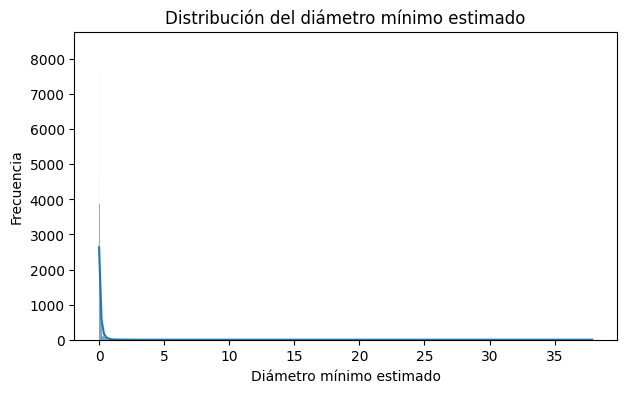

In [21]:
# Distribución del diámetro mínimo estimado
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="est_diameter_min", kde=True)
plt.title("Distribución del diámetro mínimo estimado")
plt.xlabel("Diámetro mínimo estimado")
plt.ylabel("Frecuencia")
plt.show()

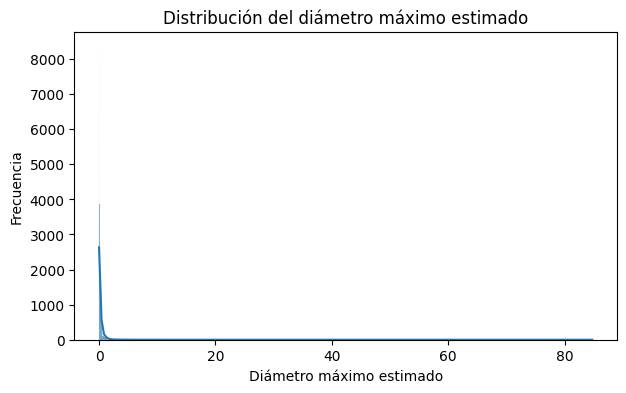

In [22]:
# Distribución del diámetro máximo estimado
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="est_diameter_max", kde=True)
plt.title("Distribución del diámetro máximo estimado")
plt.xlabel("Diámetro máximo estimado")
plt.ylabel("Frecuencia")
plt.show()

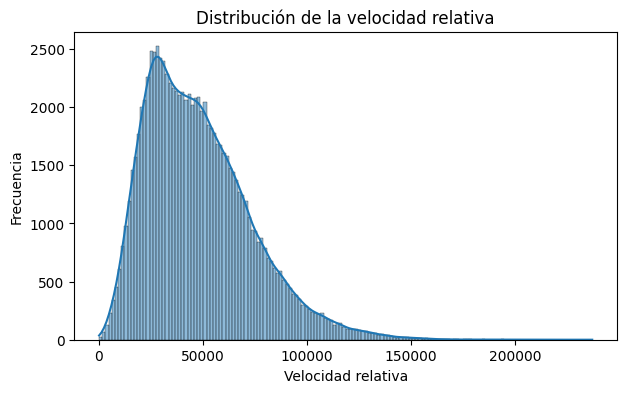

In [23]:
# Distribución de la velocidad relativa
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="relative_velocity", kde=True)
plt.title("Distribución de la velocidad relativa")
plt.xlabel("Velocidad relativa")
plt.ylabel("Frecuencia")
plt.show()

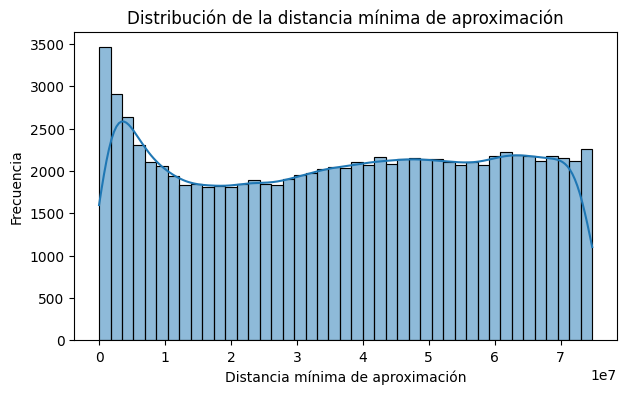

In [24]:
# Distribución de la distancia mínima de aproximación
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="miss_distance", kde=True)
plt.title("Distribución de la distancia mínima de aproximación")
plt.xlabel("Distancia mínima de aproximación")
plt.ylabel("Frecuencia")
plt.show()

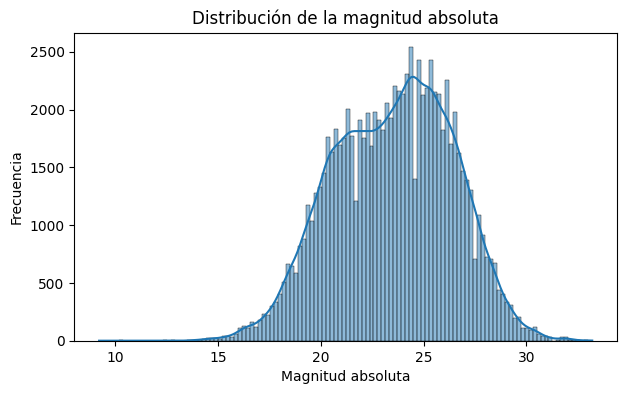

In [25]:
# Distribución de la magnitud absoluta
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="absolute_magnitude", kde=True)
plt.title("Distribución de la magnitud absoluta")
plt.xlabel("Magnitud absoluta")
plt.ylabel("Frecuencia")
plt.show()

### Justificación de los histogramas

Los histogramas permiten ver si las variables están concentradas, dispersas o si presentan valores extremos.  
Esto ayuda a decidir si conviene escalar los datos.

En este caso, las variables tienen escalas muy distintas. Por ejemplo, la distancia de aproximación puede tener valores mucho más grandes que el diámetro.  

Por eso se utilizará `StandardScaler` dentro de un `Pipeline` para que modelos sensibles a la escala, como Regresión Logística, PCA y KMeans, trabajen de forma más adecuada.

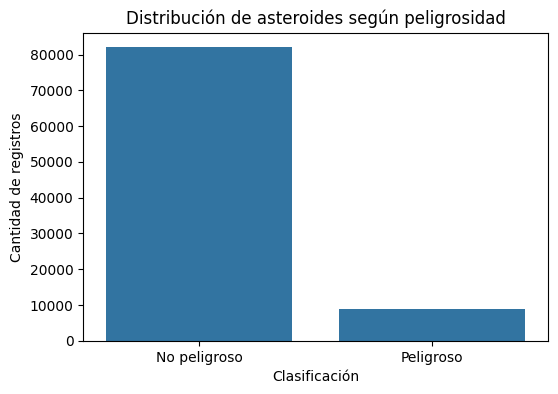

In [26]:
df["hazardous_label"] = df["hazardous"].map({False: "No peligroso", True: "Peligroso"})

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="hazardous_label")
plt.title("Distribución de asteroides según peligrosidad")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de registros")
plt.show()

### Justificación de la matriz de correlación

La matriz de correlación ayuda a observar relaciones lineales entre variables numéricas.

No se usa como único criterio para elegir variables, porque un modelo puede encontrar relaciones no lineales que la correlación no muestra.  
Sin embargo, sirve como apoyo para entender el dataset y detectar variables que podrían estar relacionadas entre sí.

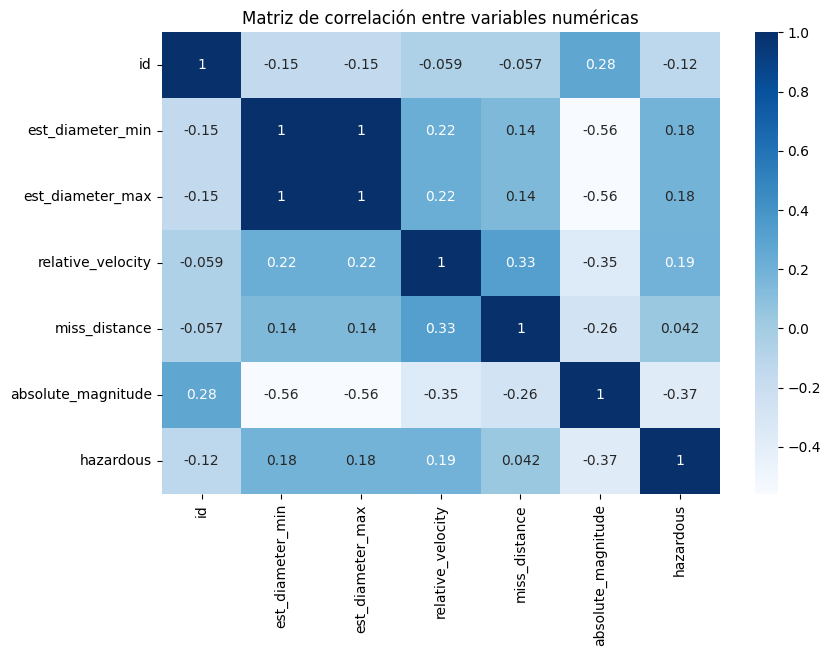

In [27]:
df_corr = df[columnas_numericas + ["hazardous"]].copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)

plt.figure(figsize=(9, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap="Blues")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

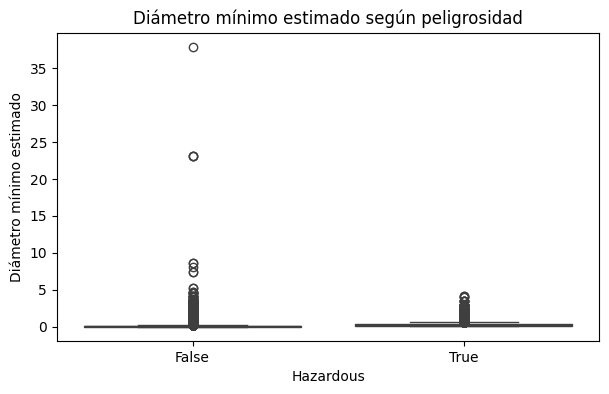

In [28]:
# Diámetro mínimo estimado según peligrosidad
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="hazardous", y="est_diameter_min")
plt.title("Diámetro mínimo estimado según peligrosidad")
plt.xlabel("Hazardous")
plt.ylabel("Diámetro mínimo estimado")
plt.show()

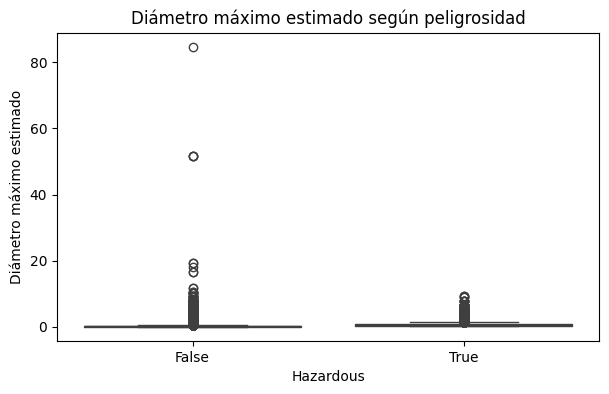

In [29]:
# Diámetro máximo estimado según peligrosidad
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="hazardous", y="est_diameter_max")
plt.title("Diámetro máximo estimado según peligrosidad")
plt.xlabel("Hazardous")
plt.ylabel("Diámetro máximo estimado")
plt.show()

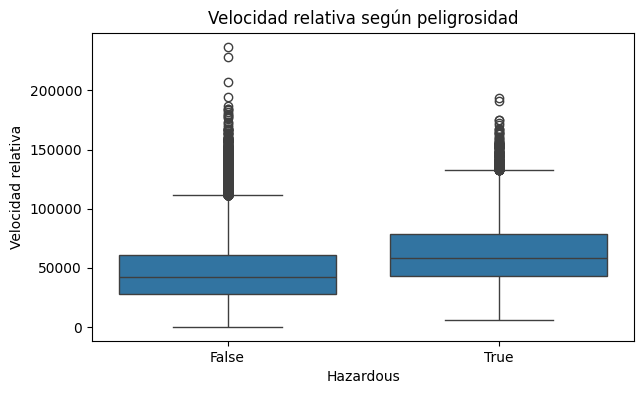

In [30]:
# Velocidad relativa según peligrosidad
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="hazardous", y="relative_velocity")
plt.title("Velocidad relativa según peligrosidad")
plt.xlabel("Hazardous")
plt.ylabel("Velocidad relativa")
plt.show()

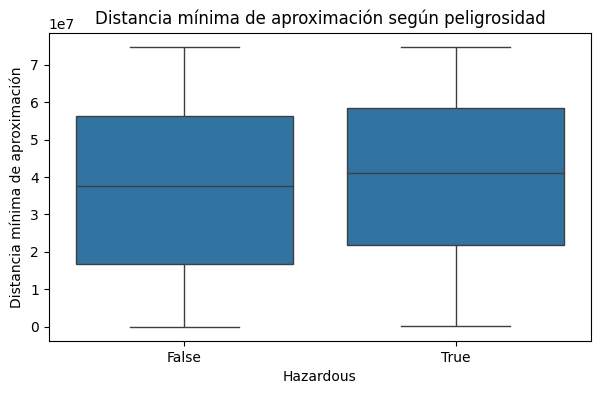

In [31]:
# Distancia mínima de aproximación según peligrosidad
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="hazardous", y="miss_distance")
plt.title("Distancia mínima de aproximación según peligrosidad")
plt.xlabel("Hazardous")
plt.ylabel("Distancia mínima de aproximación")
plt.show()

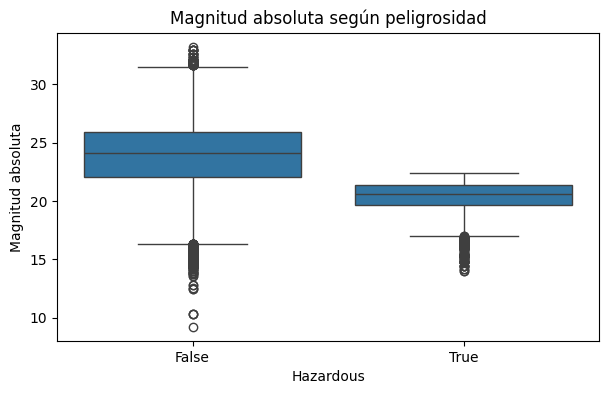

In [32]:
# Magnitud absoluta según peligrosidad
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="hazardous", y="absolute_magnitude")
plt.title("Magnitud absoluta según peligrosidad")
plt.xlabel("Hazardous")
plt.ylabel("Magnitud absoluta")
plt.show()

### Interpretación de los boxplots

En los boxplots se observan diferencias visuales entre asteroides peligrosos y no peligrosos, especialmente en variables asociadas al tamaño estimado y a la magnitud absoluta.

Esto sugiere que estas variables pueden aportar información útil al modelo supervisado. En cambio, variables como velocidad relativa y distancia de aproximación pueden necesitar analizarse junto con otras variables para entregar una separación más clara.

Se detectaron posibles outliers con el método IQR. Sin embargo, no se eliminaron automáticamente porque pueden representar asteroides reales con características poco frecuentes. Se decidió mantenerlos y controlar su efecto mediante el escalado de variables numéricas antes del modelado.

## 7. Selección y preparación de variables

Para el modelado supervisado se define:

- `X`: variables predictoras.
- `y`: variable objetivo (`hazardous`).

Se eliminan `id` y `name` porque son identificadores. Aunque pueden diferenciar registros, no representan características físicas del asteroide.

Usarlas podría hacer que el modelo memorice objetos en lugar de aprender patrones generales. Por eso no se consideran adecuadas para la predicción.

In [33]:
# Variable objetivo
y = df["hazardous"].astype(int)

# Variables que no se usarán como predictoras
columnas_eliminar = ["hazardous", "id", "name"]

X = df.drop(columns=columnas_eliminar)

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print("hazardous")

Variables predictoras:
['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous_label']

Variable objetivo:
hazardous


In [34]:
# Identificación de columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)

Columnas numéricas: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
Columnas categóricas: ['orbiting_body', 'sentry_object', 'hazardous_label']


### Justificación del preprocesamiento

Se separan variables numéricas y categóricas porque no se preparan de la misma manera:

- Las variables numéricas se escalan con `StandardScaler`.
- Las variables categóricas se transforman con `OneHotEncoder`.

Se utiliza `ColumnTransformer` porque permite aplicar distintas transformaciones a distintas columnas dentro de una misma estructura.

Se utiliza `Pipeline` porque une el preprocesamiento y el modelo en un solo flujo. Esto evita errores y mejora la reproducibilidad del proyecto.

In [35]:
# OneHotEncoder cambió el nombre del parámetro sparse en algunas versiones de sklearn.
# Este bloque permite que el notebook funcione en más versiones.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ]
)

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


## 8. División entre entrenamiento y prueba

Se divide el dataset en entrenamiento y prueba.

- El conjunto de entrenamiento se usa para aprender patrones.
- El conjunto de prueba se reserva para evaluar el rendimiento en datos no vistos.

Se utiliza `stratify=y` para mantener una proporción similar de asteroides peligrosos y no peligrosos en ambos conjuntos.  
Esta decisión es importante porque la variable objetivo está desbalanceada.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Distribución y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True))

Tamaño X_train: (72668, 8)
Tamaño X_test: (18168, 8)
Distribución y_train:
hazardous
0   0.9027
1   0.0973
Name: proportion, dtype: float64

Distribución y_test:
hazardous
0   0.9027
1   0.0973
Name: proportion, dtype: float64


## 9. Modelado supervisado

Se trabajará con dos modelos supervisados vistos en los materiales:

1. **Regresión Logística**
2. **Árbol de Decisión**

### ¿Por qué Regresión Logística?

Se utiliza como modelo base porque es simple, rápido e interpretable.  
Aunque se llama “regresión”, se usa para clasificación binaria, como en este caso.

### ¿Por qué Árbol de Decisión?

Se utiliza porque permite capturar relaciones no lineales entre variables y es fácil de explicar mediante reglas de decisión.

### ¿Por qué no usar modelos más avanzados?

Se decidió no usar modelos como Random Forest porque el objetivo es mantenerse dentro de las herramientas entregadas en los notebooks de referencia.  
La prioridad es que el desarrollo sea defendible y coherente con lo trabajado en clases.

In [37]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Árbol de Decisión": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
}

resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "F1-score clase peligrosa": f1
    })

    modelos_entrenados[nombre] = pipeline

resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,F1-score clase peligrosa
0,Regresión Logística,1.0000,1.0000
1,Árbol de Decisión,1.0000,1.0000


### Justificación de `class_weight="balanced"`

La clase `hazardous=True` es menos frecuente que `hazardous=False`.  
Por eso se usa `class_weight="balanced"`, para que el modelo entregue mayor importancia relativa a la clase minoritaria durante el entrenamiento.

Esta decisión busca evitar que el modelo se incline demasiado por la clase mayoritaria y mejore su capacidad para detectar asteroides potencialmente peligrosos.

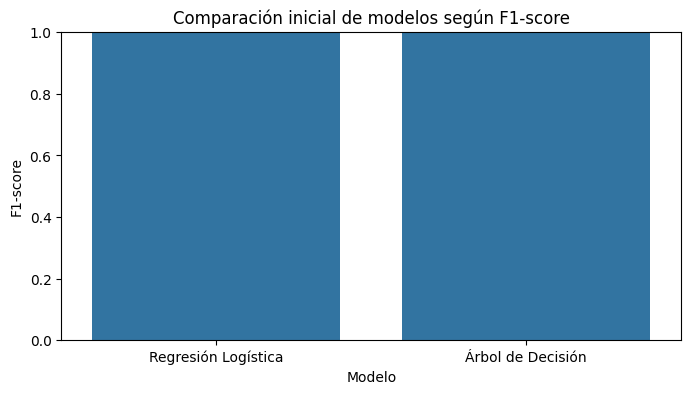

In [38]:
plt.figure(figsize=(8, 4))
sns.barplot(data=resultados_df, x="Modelo", y="F1-score clase peligrosa")
plt.title("Comparación inicial de modelos según F1-score")
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.show()

## 10. Reportes de clasificación y matrices de confusión

Se revisan las métricas de cada modelo con `classification_report` y `confusion_matrix`.

El `classification_report` muestra precision, recall y f1-score por clase.  
Esto es importante porque el problema está desbalanceado.

La matriz de confusión permite ver directamente:

- Verdaderos negativos.
- Falsos positivos.
- Falsos negativos.
- Verdaderos positivos.

En este problema, los falsos negativos son especialmente relevantes, porque significan asteroides peligrosos clasificados como no peligrosos.

Regresión Logística
Reporte de clasificación:
              precision    recall  f1-score   support

No peligroso       1.00      1.00      1.00     16400
   Peligroso       1.00      1.00      1.00      1768

    accuracy                           1.00     18168
   macro avg       1.00      1.00      1.00     18168
weighted avg       1.00      1.00      1.00     18168

Matriz de confusión:
[[16400     0]
 [    0  1768]]


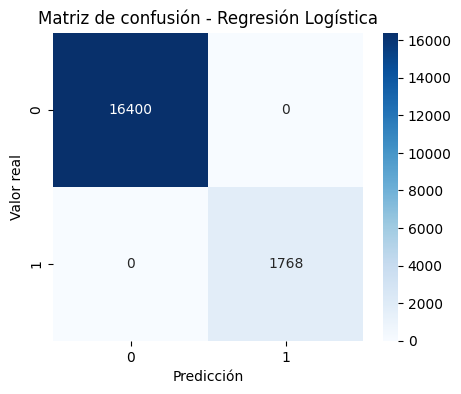

Árbol de Decisión
Reporte de clasificación:
              precision    recall  f1-score   support

No peligroso       1.00      1.00      1.00     16400
   Peligroso       1.00      1.00      1.00      1768

    accuracy                           1.00     18168
   macro avg       1.00      1.00      1.00     18168
weighted avg       1.00      1.00      1.00     18168

Matriz de confusión:
[[16400     0]
 [    0  1768]]


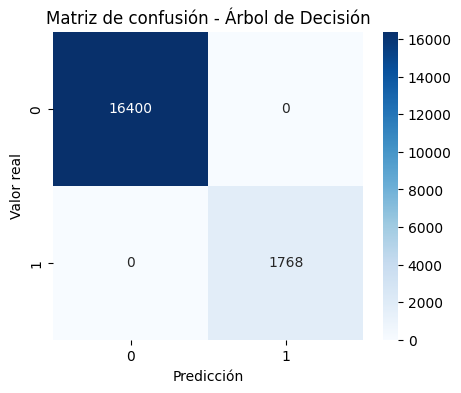

In [39]:
for nombre, pipeline in modelos_entrenados.items():
    print("=" * 80)
    print(nombre)
    print("=" * 80)

    y_pred = pipeline.predict(X_test)

    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=["No peligroso", "Peligroso"]))

    matriz = confusion_matrix(y_test, y_pred)
    print("Matriz de confusión:")
    print(matriz)

    plt.figure(figsize=(5, 4))
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

## 11. Validación cruzada usando GridSearchCV

Para evaluar los modelos de forma más estable se usa validación cruzada.

En vez de importar una herramienta adicional, se usa `GridSearchCV` con una grilla vacía.  
Esto permite aplicar validación cruzada sobre el modelo sin cambiar sus hiperparámetros.

La decisión se tomó para mantener el notebook dentro de las herramientas ya trabajadas y, al mismo tiempo, cumplir con la evaluación comparativa de modelos.

In [40]:
cv_resultados = []

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    cv_model = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        scoring="f1",
        cv=5
    )

    cv_model.fit(X_train, y_train)

    cv_resultados.append({
        "Modelo": nombre,
        "F1 promedio CV": cv_model.cv_results_["mean_test_score"][0],
        "Desviación estándar CV": cv_model.cv_results_["std_test_score"][0]
    })

cv_resultados_df = pd.DataFrame(cv_resultados)
cv_resultados_df

,Modelo,F1 promedio CV,Desviación estándar CV
0,Regresión Logística,1.0000,0.0000
1,Árbol de Decisión,1.0000,0.0000


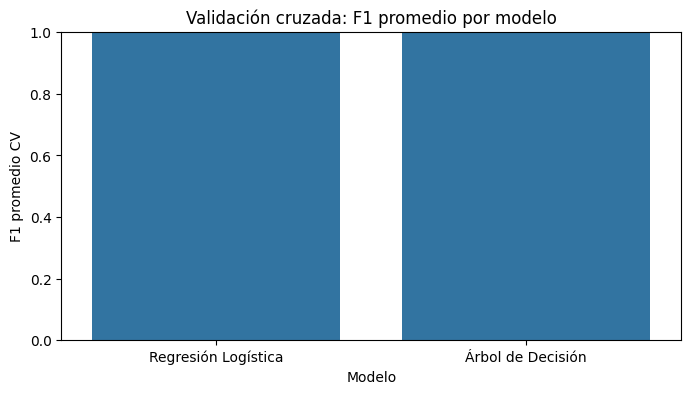

In [41]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_resultados_df, x="Modelo", y="F1 promedio CV")
plt.title("Validación cruzada: F1 promedio por modelo")
plt.ylabel("F1 promedio CV")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.show()

### Interpretación de la validación cruzada

La validación cruzada entrega una estimación más confiable que una sola división train/test, porque el modelo se entrena y evalúa varias veces usando distintas particiones.

Se revisa tanto el promedio como la desviación estándar:

- Un promedio alto indica buen rendimiento general.
- Una desviación baja indica que el modelo es más estable entre particiones.

## 12. Optimización de hiperparámetros

La optimización busca mejorar el rendimiento de los modelos probando distintas configuraciones.

Se usan dos métodos:

- `GridSearchCV` para Regresión Logística.
- `RandomizedSearchCV` para Árbol de Decisión.

### ¿Por qué GridSearchCV en Regresión Logística?

Porque se probará una grilla pequeña de valores. En ese caso, revisar todas las combinaciones es razonable.

### ¿Por qué RandomizedSearchCV en Árbol de Decisión?

Porque los árboles tienen más hiperparámetros posibles. RandomizedSearchCV permite probar una muestra de combinaciones y reducir costo computacional.

In [42]:
# Optimización de Regresión Logística con GridSearchCV

pipeline_logistica = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

param_grid_logistica = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear"]
}

grid_logistica = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid=param_grid_logistica,
    scoring="f1",
    cv=5
)

grid_logistica.fit(X_train, y_train)

print("Mejores parámetros Regresión Logística:")
print(grid_logistica.best_params_)
print("Mejor F1 en validación cruzada:", grid_logistica.best_score_)

Mejores parámetros Regresión Logística:
{'model__C': 0.01, 'model__solver': 'liblinear'}
Mejor F1 en validación cruzada: 1.0


In [58]:
# Optimización de Árbol de Decisión con RandomizedSearchCV


pipeline_arbol = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])

param_random_arbol = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20, 50],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

random_arbol = RandomizedSearchCV(
    estimator=pipeline_arbol,
    param_distributions=param_random_arbol,
    n_iter=25,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE
)

random_arbol.fit(X_train, y_train)

print("Mejores parámetros Árbol de Decisión:")
print(random_arbol.best_params_)
print("Mejor F1 en validación cruzada:", random_arbol.best_score_)

Mejores parámetros Árbol de Decisión:
{'model__min_samples_split': 50, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__criterion': 'entropy'}
Mejor F1 en validación cruzada: 1.0


## 13. Comparación final de modelos optimizados

Ahora se comparan los modelos después de la optimización de hiperparámetros.

Se usa el conjunto de prueba para evaluar cómo se comportan los modelos optimizados frente a datos no usados durante el entrenamiento ni durante la búsqueda de hiperparámetros.

In [44]:
modelos_optimizados = {
    "Regresión Logística optimizada": grid_logistica.best_estimator_,
    "Árbol de Decisión optimizado": random_arbol.best_estimator_
}

resultados_finales = []

for nombre, modelo in modelos_optimizados.items():
    y_pred = modelo.predict(X_test)

    resultados_finales.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision clase peligrosa": precision_score(y_test, y_pred),
        "Recall clase peligrosa": recall_score(y_test, y_pred),
        "F1-score clase peligrosa": f1_score(y_test, y_pred)
    })

resultados_finales_df = pd.DataFrame(resultados_finales)
resultados_finales_df

,Modelo,Accuracy,Precision clase peligrosa,Recall clase peligrosa,F1-score clase peligrosa
0,Regresión Logística optimizada,1.0000,1.0000,1.0000,1.0000
1,Árbol de Decisión optimizado,1.0000,1.0000,1.0000,1.0000


### Interpretación de las métricas finales

Además del accuracy y el F1-score, se revisan precision y recall para la clase peligrosa.

El recall es importante porque muestra cuántos asteroides peligrosos logra detectar el modelo. En este problema, un falso negativo sería delicado, ya que significaría clasificar como no peligroso un asteroide que sí era peligroso.

La precision también se considera porque permite observar cuántas falsas alarmas genera el modelo al predecir la clase peligrosa.

In [45]:
comparacion_total = pd.concat([
    resultados_df.assign(Etapa="Inicial"),
    resultados_finales_df.assign(Etapa="Optimizado")
], ignore_index=True)

comparacion_total

,Modelo,Accuracy,F1-score clase peligrosa,Etapa,Precision clase peligrosa,Recall clase peligrosa
0,Regresión Logística,1.0000,1.0000,Inicial,NaN,NaN
1,Árbol de Decisión,1.0000,1.0000,Inicial,NaN,NaN
2,Regresión Logística optimizada,1.0000,1.0000,Optimizado,1.0000,1.0000
3,Árbol de Decisión optimizado,1.0000,1.0000,Optimizado,1.0000,1.0000


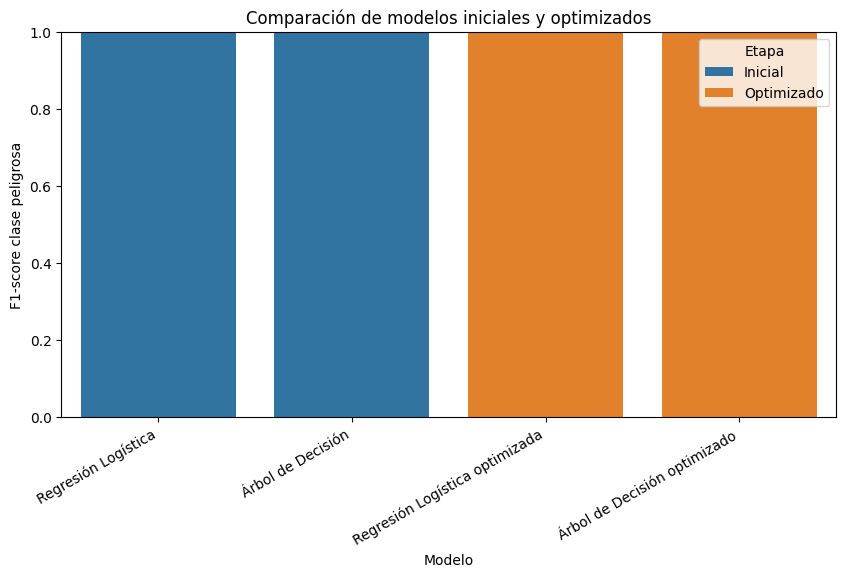

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparacion_total, x="Modelo", y="F1-score clase peligrosa", hue="Etapa")
plt.title("Comparación de modelos iniciales y optimizados")
plt.ylabel("F1-score clase peligrosa")
plt.xlabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()

Regresión Logística optimizada
              precision    recall  f1-score   support

No peligroso       1.00      1.00      1.00     16400
   Peligroso       1.00      1.00      1.00      1768

    accuracy                           1.00     18168
   macro avg       1.00      1.00      1.00     18168
weighted avg       1.00      1.00      1.00     18168



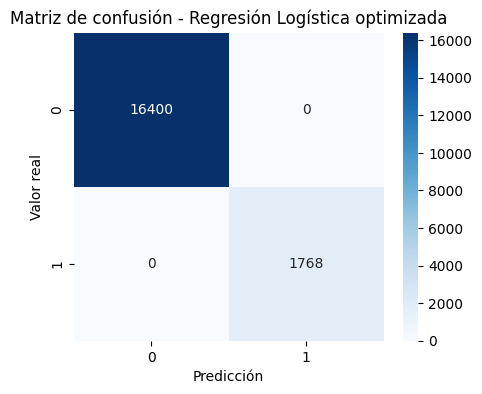

Árbol de Decisión optimizado
              precision    recall  f1-score   support

No peligroso       1.00      1.00      1.00     16400
   Peligroso       1.00      1.00      1.00      1768

    accuracy                           1.00     18168
   macro avg       1.00      1.00      1.00     18168
weighted avg       1.00      1.00      1.00     18168



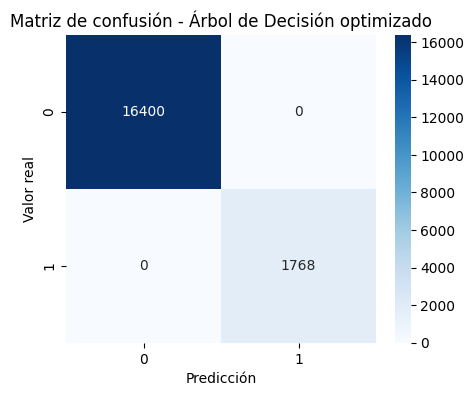

In [47]:
for nombre, modelo in modelos_optimizados.items():
    print(nombre)
    y_pred = modelo.predict(X_test)

    print(classification_report(y_test, y_pred, target_names=["No peligroso", "Peligroso"]))

    matriz = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

### Criterio para elegir el modelo final

El modelo final no se selecciona solamente por `accuracy`, porque la clase peligrosa es minoritaria.

En este contexto es importante revisar el `f1-score` de la clase peligrosa, ya que combina precision y recall.  
Esto permite evaluar si el modelo logra detectar objetos peligrosos sin depender únicamente de la clase mayoritaria.

Si dos modelos tienen resultados similares, también se considera la interpretabilidad:

- Regresión Logística es más simple y estable.
- Árbol de Decisión es más fácil de explicar mediante reglas, pero puede sobreajustarse si no se controla su profundidad.

In [48]:
mejor_indice = resultados_finales_df["F1-score clase peligrosa"].idxmax()
mejor_modelo_nombre = resultados_finales_df.loc[mejor_indice, "Modelo"]
mejor_f1 = resultados_finales_df.loc[mejor_indice, "F1-score clase peligrosa"]

print("Modelo seleccionado según F1-score de la clase peligrosa:")
print(mejor_modelo_nombre)
print("F1-score:", mejor_f1)

Modelo seleccionado según F1-score de la clase peligrosa:
Regresión Logística optimizada
F1-score: 1.0


## 14. Aprendizaje no supervisado: PCA y KMeans

Además del modelo supervisado, se aplica aprendizaje no supervisado para explorar patrones sin utilizar la etiqueta `hazardous`.

Se utilizarán dos técnicas:

1. **PCA:** reducción de dimensionalidad.
2. **KMeans:** agrupamiento de asteroides según características similares.

### ¿Por qué PCA?

Porque permite reducir varias variables a dos componentes principales para visualizar los datos en un plano 2D.  
Esto ayuda a observar si existen separaciones naturales entre los registros.

### ¿Por qué KMeans?

Porque es un método de clustering simple y conocido.  
Permite agrupar asteroides según similitud, sin entregarle al modelo la respuesta real de peligrosidad.

In [49]:
# Para aprendizaje no supervisado se usan las mismas variables predictoras,
# pero sin ocupar la variable hazardous como entrada.

X_preparado = preprocessor.fit_transform(X)

print("Datos transformados para PCA y KMeans:", X_preparado.shape)

Datos transformados para PCA y KMeans: (90836, 9)


In [50]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_preparado)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["hazardous"] = y.values

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

pca_df.head()

Varianza explicada por cada componente:
[0.51594425 0.2274819 ]
Varianza explicada total: 0.7434261492382503


,PC1,PC2,hazardous
0,4.8938,-2.4291,0
1,1.7501,1.1301,1
2,4.0682,0.7418,0
3,-0.3002,-0.7753,0
4,1.1749,-0.0050,1


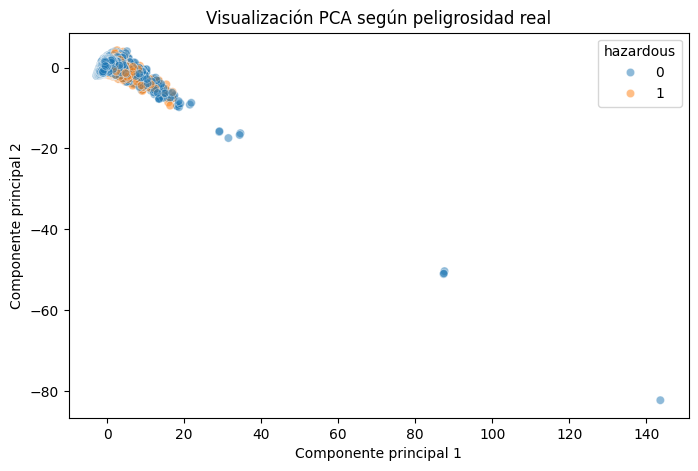

In [51]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="hazardous", alpha=0.5)
plt.title("Visualización PCA según peligrosidad real")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

### Interpretación de PCA

PCA no se usa aquí para predecir, sino para visualizar.  
La etiqueta `hazardous` solo se agrega al gráfico después de calcular PCA, para observar si los asteroides peligrosos se distribuyen de forma distinta.

Esto es importante porque el aprendizaje no supervisado no debe usar la variable objetivo para entrenar.

## 15. Elección de cantidad de clusters con KMeans

Se prueban distintos valores de `k` y se evalúan con `silhouette_score`.

El `silhouette_score` permite medir qué tan bien separados están los clusters:

- Valores cercanos a 1 indican clusters mejor separados.
- Valores cercanos a 0 indican clusters solapados.
- Valores negativos indican asignaciones poco adecuadas.

In [52]:
resultados_k = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    score = silhouette_score(
        X_pca,
        clusters,
        sample_size=10000,
        random_state=RANDOM_STATE
    )
    resultados_k.append({
        "k": k,
        "silhouette_score": score
    })

resultados_k_df = pd.DataFrame(resultados_k)
resultados_k_df

,k,silhouette_score
0,2,0.4474
1,3,0.4336
2,4,0.4346
3,5,0.4083
4,6,0.3757
5,7,0.4069


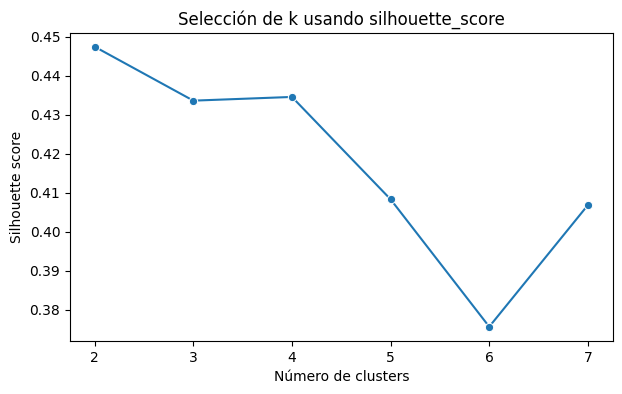

In [53]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=resultados_k_df, x="k", y="silhouette_score", marker="o")
plt.title("Selección de k usando silhouette_score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.show()

In [54]:
mejor_k = int(resultados_k_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Mejor valor de k según silhouette_score:", mejor_k)

kmeans_final = KMeans(n_clusters=mejor_k, random_state=RANDOM_STATE, n_init=10)
pca_df["cluster"] = kmeans_final.fit_predict(X_pca)

pca_df.head()

Mejor valor de k según silhouette_score: 2


,PC1,PC2,hazardous,cluster
0,4.8938,-2.4291,0,0
1,1.7501,1.1301,1,0
2,4.0682,0.7418,0,0
3,-0.3002,-0.7753,0,1
4,1.1749,-0.0050,1,0


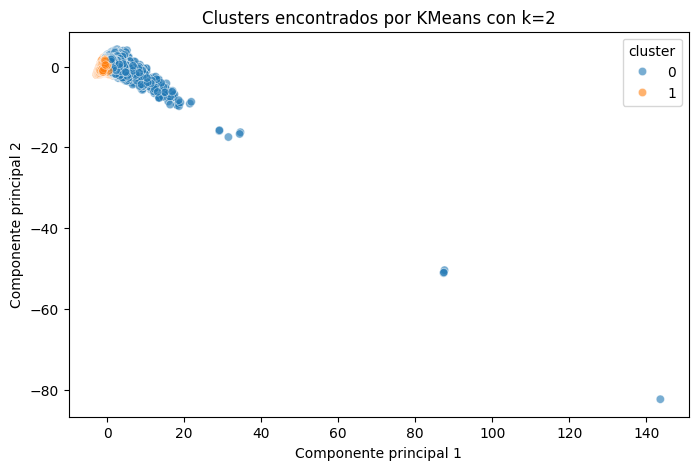

In [55]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.6)
plt.title(f"Clusters encontrados por KMeans con k={mejor_k}")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

In [56]:
comparacion_cluster_hazardous = pd.crosstab(
    pca_df["cluster"],
    pca_df["hazardous"],
    normalize="index"
) * 100

comparacion_cluster_hazardous

hazardous,0,1
cluster,,
0,76.7931,23.2069
1,96.9373,3.0627


### Interpretación del clustering

El clustering permite observar si existen grupos naturales de asteroides según sus características físicas y orbitales.

KMeans se entrenó usando todos los registros transformados. Para el cálculo del `silhouette_score` se usó una muestra de 10.000 registros, porque esta métrica puede tardar bastante en datasets grandes. Esto permite mantener una evaluación razonable y reproducible.

Luego se compara cada cluster con la variable `hazardous`, pero solo como análisis posterior. Es decir, KMeans no recibió la etiqueta durante el entrenamiento.

Si algún cluster concentra mayor porcentaje de asteroides peligrosos, puede interpretarse como un grupo con características de mayor riesgo relativo. Si los porcentajes son similares, significa que la peligrosidad no se separa claramente solo mediante estos clusters en dos dimensiones.

## 16. Conclusiones finales

A partir del análisis realizado, se puede concluir lo siguiente:

1. El problema se abordó como clasificación supervisada porque la variable objetivo `hazardous` indica una categoría binaria.
2. Se eliminaron `id` y `name` porque son identificadores y no características predictivas reales.
3. Se usó `Pipeline` y `ColumnTransformer` para mantener un flujo ordenado, reproducible y evitar errores de preprocesamiento.
4. Se aplicó `StandardScaler` porque las variables numéricas tienen escalas muy diferentes.
5. Se utilizó `OneHotEncoder` para transformar variables categóricas sin imponer un orden artificial.
6. Se compararon Regresión Logística y Árbol de Decisión porque representan dos enfoques distintos: uno lineal e interpretable, y otro basado en reglas de decisión.
7. La evaluación no se basó solo en accuracy, porque el dataset está desbalanceado.
8. Se revisaron precision, recall y F1-score para analizar mejor el rendimiento sobre la clase peligrosa.
9. La optimización de hiperparámetros permitió analizar si el rendimiento mejoraba frente a los modelos iniciales.
10. PCA y KMeans permitieron explorar patrones sin usar la etiqueta objetivo.

## Recomendaciones

Para una siguiente etapa se recomienda:

- Probar más modelos supervisados si el curso lo permite.
- Revisar técnicas adicionales para datasets desbalanceados.
- Analizar más profundamente los falsos negativos, ya que son los casos más delicados en este problema.
- Complementar el análisis con información astronómica adicional si estuviera disponible.

## 17. Resumen de decisiones metodológicas

| Decisión | Justificación |
|---|---|
| Usar `hazardous` como objetivo | Es una variable binaria que representa un problema real de clasificación. |
| No usar `id` ni `name` | Son identificadores, no características físicas del asteroide. |
| Usar clasificación | La variable objetivo es categórica, no numérica continua. |
| Usar Regresión Logística | Modelo simple, interpretable y adecuado como base. |
| Usar Árbol de Decisión | Permite trabajar con reglas no lineales y es fácil de explicar. |
| No usar Random Forest | Se priorizaron modelos más simples para mantener el análisis interpretable y acorde al alcance del curso. |
| Usar `Pipeline` | Ordena el flujo y mejora la reproducibilidad. |
| Usar `ColumnTransformer` | Permite transformar variables numéricas y categóricas de forma distinta. |
| Usar `StandardScaler` | Las variables numéricas tienen escalas diferentes. |
| Usar `OneHotEncoder` | Permite usar variables categóricas dentro de modelos de Scikit-learn. |
| Usar `stratify=y` | Mantiene la proporción de clases en entrenamiento y prueba. |
| Usar precision, recall y F1-score | Entrega una evaluación más completa cuando hay desbalance de clases. |
| Usar GridSearchCV | Permite validación cruzada y búsqueda ordenada de hiperparámetros. |
| Usar RandomizedSearchCV | Permite explorar hiperparámetros de forma más eficiente. |
| Usar PCA + KMeans | Se usó para revisar si aparecen grupos naturales entre los asteroides. |